# FHeat — Eine Einführung für Anwender

Dieses Notebook führt Schritt für Schritt durch eine vollständige Wärmenetzanalyse mit dem Python-Paket **FHeat**.

**Beispielregion**: Burgsteinfurt (NRW) — Daten kommen kostenlos vom Open-Geodata-Portal NRW.

**Was du am Ende hast**:
- bereinigte Gebäude- und Straßendaten
- Wärmedichte-Blöcke (zeigt, wo sich ein Wärmenetz lohnt)
- ein berechnetes Wärmenetz mit Rohrdimensionierung und Verlusten
- alles als GeoPackage (`.gpkg`) — direkt in QGIS ladbar

**Voraussetzungen**:
- `planungsgebiet.gpkg` liegt im selben Ordner wie dieses Notebook
- das Paket `fheat` ist mit dem NRW-Adapter installiert (`pip install -e ".[nrw]"` im Repo-Root)

## 1. Importe

Wir brauchen vier FHeat-Bausteine und drei Standard-Bibliotheken:

| Import | Wofür |
|---|---|
| `FHeatConfig` | Container für Berechnungsparameter (Temperaturen, Schwellenwerte, ...) |
| `FHeatOrchestrator` | Der "Dirigent". Ruft die Pipeline-Schritte in der richtigen Reihenfolge auf. |
| `Phase` | Enum mit den Stufen `INITIAL → DOWNLOADED → ADJUSTED → STATUS → NETWORK → RESULTS`. Brauchen wir, um einzelne Schritte gezielt auszulösen. |
| `NRWDataAdapter` | Lädt NRW-Rohdaten und liefert sie schemakonform an die Pipeline. |
| `geopandas` | Zum Einlesen des Planungsgebiets. |
| `matplotlib.pyplot` | Zum Visualisieren des Lastprofils. |
| `pathlib.Path` | Saubere, plattformunabhängige Pfade. |

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt

from fheat_core import columns as cols
from fheat_core.config import FHeatConfig
from fheat_core.orchestrator import FHeatOrchestrator
from fheat_core.state import Phase
from fheat_nrw.adapter.data_adapter import NRWDataAdapter

## 2. Arbeitsverzeichnis und Ausgabeordner

Alles, was die Pipeline produziert, landet in einem Unterordner `output_burgsteinfurt/` direkt neben dem Notebook.

`Path.cwd()` liefert das aktuelle Arbeitsverzeichnis — in Jupyter ist das standardmäßig der Notebook-Ordner.

In [2]:
NOTEBOOK_DIR = Path.cwd()
OUTPUT_DIR = NOTEBOOK_DIR / "output_burgsteinfurt"
OUTPUT_DIR.mkdir(exist_ok=True)

AREA_PATH = NOTEBOOK_DIR / "planungsgebiet.gpkg"

print(f"Notebook-Ordner:  {NOTEBOOK_DIR}")
print(f"Ausgaben in:      {OUTPUT_DIR}")
print(f"Planungsgebiet:   {AREA_PATH}  (existiert: {AREA_PATH.exists()})")

Notebook-Ordner:  c:\Users\Sommer\Documents\Projects\260505_fheat-package\examples
Ausgaben in:      c:\Users\Sommer\Documents\Projects\260505_fheat-package\examples\output_burgsteinfurt
Planungsgebiet:   c:\Users\Sommer\Documents\Projects\260505_fheat-package\examples\planungsgebiet.gpkg  (existiert: True)


## 3. Adapter und Konfiguration

Der **Adapter** weiß, *woher* die Daten kommen — hier `NRWDataAdapter` für Burgsteinfurt:
- `city_name="Burgsteinfurt"` — Stadtteilname (Burgsteinfurt gehört zur Gemeinde Steinfurt)
- `source_coordinates=(52.1592, 7.3268)` — Lage der geplanten Wärmequelle als (Breitengrad, Längengrad)
- `heat_attribute="RW_WW"` — Spaltenname für den Wärmebedarf in den NRW-Rohdaten

Die **Config** enthält ausschließlich *Berechnungs*parameter — bewusst getrennt von der Datenquelle. So bleibt der Code austauschbar: dieselbe Pipeline läuft mit anderem Adapter z. B. auf eigenen Daten.

In [3]:
adapter = NRWDataAdapter(
    city_name="Burgsteinfurt",
    source_coordinates=(52.1592, 7.3268),
    heat_attribute="RW_WW",
)

config = FHeatConfig(
    supply_temperature=80.0,    # Vorlauf in °C
    return_temperature=50.0,    # Rücklauf in °C
    wld_threshold=500.0,        # WLD-Schwelle [kWh/(a·m)] — ab hier lohnt ein Netz
    buffer_distance=50.0,       # Pufferradius für Eignungspolygone [m]
    year=2022,                  # Kalenderjahr für das Lastprofil
    output_dir=str(OUTPUT_DIR),
    output_format="gpkg",
)

orch = FHeatOrchestrator(config=config, adapter=adapter)
print("Orchestrator bereit — aktuelle Phase:", orch.state.phase.value)

Orchestrator bereit — aktuelle Phase: initial


## 4. Daten herunterladen — Gebäude, Straßen, Flurstücke

`run_step(Phase.INITIAL)` ruft beim Adapter `fetch_buildings()`, `fetch_streets()`, `fetch_parcels()` und `fetch_source()` auf. Der NRW-Adapter holt dabei:

- **Gebäude** mit Wärmebedarfsmodell (Open Geodata NRW, ZIP-Download)
- **Straßen** als Wärmelinien-Layer aus demselben ZIP
- **Flurstücke** über den ALKIS-Webdienst (WFS)
- **Quellpunkt** aus den oben angegebenen Koordinaten

Beim ersten Aufruf dauert das ca. 1–2 Minuten (Internet).

In [4]:
orch.run_step(Phase.INITIAL)

print(f"Gebäude:     {len(orch.state.buildings_gdf):>5}")
print(f"Straßen:     {len(orch.state.streets_gdf):>5}")
print(f"Flurstücke:  {len(orch.state.parcels_gdf):>5}")
print(f"Phase jetzt: {orch.state.phase.value}")

c:\Users\Sommer\Documents\Projects\260505_fheat-package\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Field with same name (identifier) already exists in (CadastralParcel). Skipping newer ones
  return ogr_read(


Gebäude:      5588
Straßen:      2080
Flurstücke:  10009
Phase jetzt: downloaded


## 5. Daten anpassen — Clip auf das Planungsgebiet + Bereinigung

Wir schneiden Gebäude und Straßen auf das Polygon aus `planungsgebiet.gpkg` zu — nur was innerhalb liegt, wird weiter betrachtet.

Wichtig: das Planungsgebiet wird mit `to_crs()` auf das Koordinatensystem der Gebäudedaten umprojiziert, damit der räumliche Schnitt überhaupt funktioniert (sonst würde z. B. ein WGS84-Polygon auf UTM32-Daten leeren Schnitt liefern).

Direkt danach läuft der **Adjust-Schritt**: er prüft, ob alle Pflichtspalten und Geometrietypen stimmen, und repariert kaputte Polygone (`buffer(0)`-Trick).

Die angepassten Daten speichern wir als `angepasste_Gebaeude.gpkg` und `angepasste_Strassen.gpkg`.

In [5]:
# Planungsgebiet laden und auf das CRS der Gebäude bringen
area = gpd.read_file(AREA_PATH).to_crs(orch.state.buildings_gdf.crs)
area_geom = area.geometry.union_all()

# Gebäude und Straßen auf das Planungsgebiet zuschneiden
orch.state.buildings_gdf = (
    orch.state.buildings_gdf[orch.state.buildings_gdf.geometry.intersects(area_geom)]
    .reset_index(drop=True)
)
orch.state.streets_gdf = (
    orch.state.streets_gdf[orch.state.streets_gdf.geometry.intersects(area_geom)]
    .reset_index(drop=True)
)

# Adjust-Schritt: Schema validieren + Geometrien reparieren
orch.run_step(Phase.DOWNLOADED)

# Angepasste Daten ablegen (cols.to_display: kanonische → deutsche Spaltenlabels)
adj_b = OUTPUT_DIR / "angepasste_Gebaeude.gpkg"
adj_s = OUTPUT_DIR / "angepasste_Strassen.gpkg"
adj_b.unlink(missing_ok=True)
adj_s.unlink(missing_ok=True)
cols.to_display(orch.state.buildings_gdf).to_file(adj_b, driver="GPKG")
cols.to_display(orch.state.streets_gdf).to_file(adj_s, driver="GPKG")

print(f"Nach Clip: {len(orch.state.buildings_gdf)} Gebäude, {len(orch.state.streets_gdf)} Straßen")
print(f"Phase jetzt: {orch.state.phase.value}")

Nach Clip: 305 Gebäude, 81 Straßen
Phase jetzt: adjusted


## 6. Wärmedichte-Blöcke (WLD)

Die **Wärmeliniendichte (WLD)** misst den Wärmebedarf pro Meter Straße. Faustregel: ab ca. **500 kWh/(a·m)** wird ein Wärmenetz wirtschaftlich interessant — diese Schwelle haben wir oben in der Config gesetzt.

Der Status-Schritt macht drei Dinge:
1. ordnet jedes Gebäude der nächstgelegenen Straße zu,
2. summiert den Wärmebedarf pro Straßensegment und teilt ihn durch die Länge → WLD,
3. baut aus allen Flurstücken über der Schwelle die **Eignungspolygone** — jene Gebiete, in denen sich ein Netz lohnen kann.

In [6]:
orch.run_step(Phase.ADJUSTED)   # Wärmedichte-Blöcke berechnen

print(f"WLD-Segmente:       {len(orch.state.wld_gdf)}")
print(f"Eignungspolygone:   {len(orch.state.polygons_gdf)}")
print(f"Phase jetzt:        {orch.state.phase.value}")

WLD-Segmente:       81
Eignungspolygone:   1
Phase jetzt:        status


## 7. Netz berechnen und speichern

`Phase.STATUS` startet den eigentlichen Netzbau:
- die Straßen werden in einen **Graphen** umgewandelt (mit der Bibliothek NetworkX),
- jedes Gebäude bekommt eine **Hausanschlussleitung** zur nächstgelegenen Straße,
- die Wärmequelle wird ans Netz angeschlossen,
- pro Rohrabschnitt werden **Volumenstrom, Nennweite (DN), Geschwindigkeit und Wärmeverluste** berechnet.

Das Ergebnis ist `state.net_gdf` — eine Liniengeometrie mit allen Rohrkennzahlen. Wir speichern es als `netz.gpkg`.

In [7]:
orch.run_step(Phase.STATUS)   # Netzberechnung

netz_path = OUTPUT_DIR / "netz.gpkg"
netz_path.unlink(missing_ok=True)
cols.to_display(orch.state.net_gdf).to_file(netz_path, driver="GPKG")  # deutsche Spaltenlabels

print(f"Netzsegmente: {len(orch.state.net_gdf)}")
print(f"Gespeichert:  {netz_path}")

Netzsegmente: 784
Gespeichert:  c:\Users\Sommer\Documents\Projects\260505_fheat-package\examples\output_burgsteinfurt\netz.gpkg


## 8. Lastprofil und Ergebniszusammenfassung

Der letzte Pipeline-Schritt erzeugt:
- ein **stündliches Lastprofil** über das ganze Jahr (8760 Werte) auf Basis von BDEW-Standardlastprofilen,
- eine **Ergebniszusammenfassung** als Dictionary mit den wichtigsten Kennzahlen.

Die Werte unten beantworten zentrale Fragen einer Wärmenetzplanung:
- *Wie viel Wärme muss insgesamt geliefert werden?* → `total_heat_demand_mwh_a`
- *Welche Anschlussleistung braucht die Quelle?* → `total_power_glf_kw`
- *Wie viel geht im Netz verloren?* → `total_loss_mwh_a`

Anschließend wird das Lastprofil als **Tagesmittelwert-Kurve** und als **monatliche Energiemenge** geplottet.

In [8]:
orch.run_step(Phase.NETWORK)   # Lastprofil + Zusammenfassung

s = orch.state.result_summary
print("=" * 52)
print("  ERGEBNISZUSAMMENFASSUNG — Burgsteinfurt")
print("=" * 52)
print(f"  Gesamtwärmebedarf         {s['total_heat_demand_mwh_a']:>10.1f}  MWh/a")
print(f"  Angeschlossene Gebäude    {s['total_buildings']:>10d}  Stück")
print(f"  Therm. Leistung (GLF)     {s['total_power_glf_kw']:>10.1f}  kW")
print(f"  Gleichzeitigkeitsfaktor   {s['glf']:>10.3f}  -")
print(f"  Trassenlänge              {s['total_network_length_m']:>10.0f}  m")
print(f"  Netzwärmeverlust          {s['total_loss_mwh_a']:>10.1f}  MWh/a")
print(f"  Vorlauftemperatur         {s['supply_temperature_c']:>10.1f}  °C")
print(f"  Rücklauftemperatur        {s['return_temperature_c']:>10.1f}  °C")
print("=" * 52)
print(f"\nAlle Ausgaben liegen in:  {OUTPUT_DIR}")

  ERGEBNISZUSAMMENFASSUNG — Burgsteinfurt
  Gesamtwärmebedarf             8021.3  MWh/a
  Angeschlossene Gebäude           305  Stück
  Therm. Leistung (GLF)         2356.3  kW
  Gleichzeitigkeitsfaktor        0.474  -
  Trassenlänge                    9557  m
  Netzwärmeverlust              1553.9  MWh/a
  Vorlauftemperatur               80.0  °C
  Rücklauftemperatur              50.0  °C

Alle Ausgaben liegen in:  c:\Users\Sommer\Documents\Projects\260505_fheat-package\examples\output_burgsteinfurt


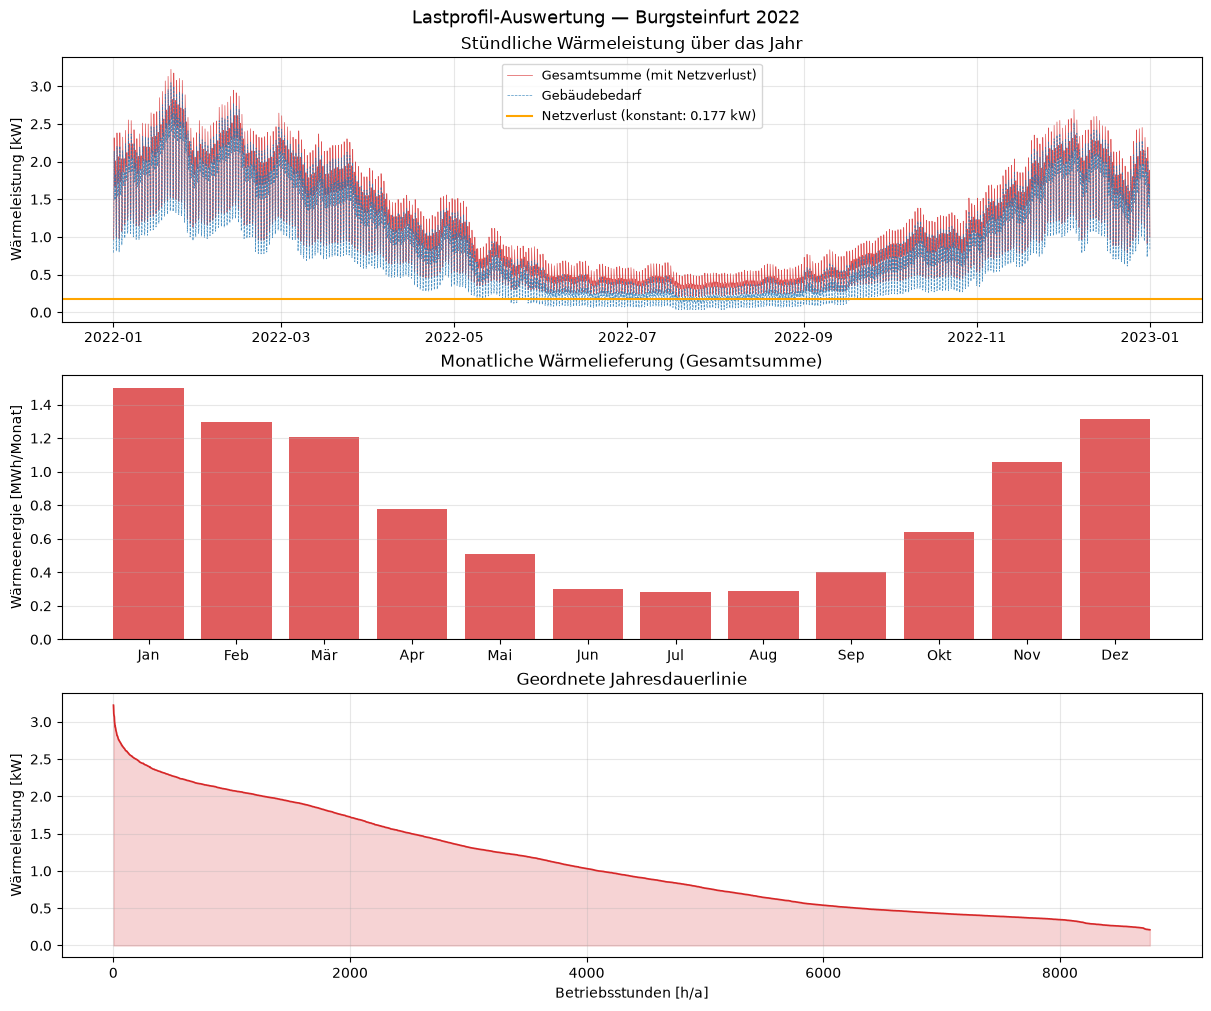

In [9]:
# cols.to_display: kanonische → deutsche Spaltenlabels für die Darstellung
lp = cols.to_display(orch.state.load_profile_df)

# Monatliche Energiemengen: Summe der Stundenwerte [kWh] ÷ 1000 → MWh
monthly_mwh = lp["Gesamtsumme"].groupby(lp.index.month).sum() / 1000
MONATE = ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun",
          "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]

# Geordnete Jahresdauerlinie: Stundenwerte absteigend sortiert
sorted_load = lp["Gesamtsumme"].sort_values(ascending=False).values

# Netzverlust: konstante stündliche Last
loss_per_hour = lp["Verlust"].iloc[0]  # alle Werte sind gleich (konstant)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)
fig.suptitle("Lastprofil-Auswertung — Burgsteinfurt 2022", fontsize=13)

# --- Stundenwerte über das Jahr ---
ax1.plot(lp.index, lp["Gesamtsumme"],
         color="tab:red", linewidth=0.5, label="Gesamtsumme (mit Netzverlust)", alpha=0.8)
ax1.plot(lp.index, lp["Summe aller Gebäudetypen"],
         color="tab:blue", linewidth=0.5, linestyle="--", label="Gebäudebedarf", alpha=0.8)
ax1.axhline(y=loss_per_hour, color="orange", linewidth=1.5, linestyle="-", label=f"Netzverlust (konstant: {loss_per_hour:.3f} kW)")
ax1.set_ylabel("Wärmeleistung [kW]")
ax1.set_title("Stündliche Wärmeleistung über das Jahr")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Monatliche Energiemenge ---
ax2.bar(range(1, 13), monthly_mwh.values, color="tab:red", alpha=0.75)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(MONATE)
ax2.set_ylabel("Wärmeenergie [MWh/Monat]")
ax2.set_title("Monatliche Wärmelieferung (Gesamtsumme)")
ax2.grid(True, alpha=0.3, axis="y")

# --- Geordnete Jahresdauerlinie ---
ax3.plot(range(1, 8761), sorted_load, color="tab:red", linewidth=1.2)
ax3.fill_between(range(1, 8761), sorted_load, alpha=0.2, color="tab:red")
ax3.set_xlabel("Betriebsstunden [h/a]")
ax3.set_ylabel("Wärmeleistung [kW]")
ax3.set_title("Geordnete Jahresdauerlinie")
ax3.grid(True, alpha=0.3)

plt.show()

## Geschafft! 🎉

Im Ordner `output_burgsteinfurt/` findest du jetzt:

| Datei | Inhalt |
|---|---|
| `angepasste_Gebaeude.gpkg` | Gebäude im Planungsgebiet, schemakonform |
| `angepasste_Strassen.gpkg` | Straßen im Planungsgebiet, schemakonform |
| `netz.gpkg` | Berechnetes Wärmenetz (mit DN, Verlust, Volumenstrom pro Segment) |

**Zum Weiterforschen**:
- öffne `netz.gpkg` in QGIS und färbe die Rohre nach `DN [mm]` ein
- ändere `wld_threshold` (z. B. auf 300) und beobachte, wie das Netz wächst
- ändere `supply_temperature` und schau, wie sich die Verluste verändern